# 🌍 AirSentinel Cameroun
## Notebook 02 — Tests Statistiques
**Responsables : BODEHOU Sabine + FANKAM Marc Aurel — ISSEA**

### Tests réalisés
1. Corrélation de Spearman (Sabine)
2. Normalité de Shapiro-Wilk (Sabine)
3. Stationnarité ADF (Marc Aurel)
4. Décomposition STL par région (Marc Aurel)
5. Détection outliers IQR + Z-score (Sabine)
6. Heatmap corrélations (Sabine)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import STL
import warnings
warnings.filterwarnings('ignore')

df = pd.read_excel('../data/processed/dataset_nettoye.xlsx')
df['date'] = pd.to_datetime(df['date'])
VAR_CIBLE = 'pm2_5_moyen'
print(f'✅ Dataset chargé : {df.shape[0]:,} lignes')

✅ Dataset chargé : 49,360 lignes


## Test 1 — Corrélation de Spearman (Sabine)
**Pourquoi Spearman ?** Non-paramétrique, fonctionne même si les données ne sont pas normales.

In [2]:
colonnes_numeriques = [c for c in df.columns
                       if df[c].dtype in ['float64', 'int64']
                       and c not in ['latitude', 'longitude', VAR_CIBLE]]

resultats = []
for col in colonnes_numeriques:
    donnees = df[[col, VAR_CIBLE]].dropna()
    if len(donnees) > 30:
        coef, pvalue = stats.spearmanr(donnees[col], donnees[VAR_CIBLE])
        resultats.append({
            'Variable':    col,
            'Corrélation': round(coef, 4),
            'P-value':     round(pvalue, 6),
            'Significatif': '✅ OUI' if pvalue < 0.05 else '❌ NON',
            'Force': 'Forte' if abs(coef) > 0.5 else 'Modérée' if abs(coef) > 0.3 else 'Faible'
        })

df_spearman = pd.DataFrame(resultats).sort_values('Corrélation', key=abs, ascending=False)
print(df_spearman.to_string(index=False))
df_spearman.to_excel('../data/processed/tests_spearman.xlsx', index=False)
print('\n✅ Résultats sauvegardés')

                   Variable  Corrélation  P-value Significatif   Force
               us_aqi_moyen       0.9704 0.000000        ✅ OUI   Forte
                 pm10_moyen       0.9525 0.000000        ✅ OUI   Forte
                  pm2_5_max       0.9467 0.000000        ✅ OUI   Forte
                 dust_moyen       0.7351 0.000000        ✅ OUI   Forte
        precipitation_hours      -0.6398 0.000000        ✅ OUI   Forte
 et0_fao_evapotranspiration       0.5940 0.000000        ✅ OUI   Forte
                ozone_moyen       0.5900 0.000000        ✅ OUI   Forte
                   rain_sum      -0.5894 0.000000        ✅ OUI   Forte
          precipitation_sum      -0.5894 0.000000        ✅ OUI   Forte
               weather_code      -0.5532 0.000000        ✅ OUI   Forte
                   co_moyen       0.5313 0.000000        ✅ OUI   Forte
                  so2_moyen       0.5236 0.000000        ✅ OUI   Forte
    shortwave_radiation_sum       0.5197 0.000000        ✅ OUI   Forte
      

## Test 2 — Normalité Shapiro-Wilk (Sabine)

In [3]:
echantillon = df.sample(min(5000, len(df)), random_state=42)
stat, pval = stats.shapiro(echantillon[VAR_CIBLE].dropna())

print(f'Test Shapiro-Wilk sur PM2.5 :')
print(f'  Statistique : {stat:.4f}')
print(f'  P-value     : {pval:.6f}')

if pval < 0.05:
    print('  → NON NORMALE → transformation log appliquée')
    df['pm2_5_log'] = np.log1p(df[VAR_CIBLE])
    print('  ✅ pm2_5_log créée')
else:
    print('  → NORMALE → pas de transformation nécessaire')

Test Shapiro-Wilk sur PM2.5 :
  Statistique : 0.7972
  P-value     : 0.000000
  → NON NORMALE → transformation log appliquée
  ✅ pm2_5_log créée


In [4]:
stat, pval = stats.shapiro(df['pm2_5_log'].dropna().sample(5000, random_state=42))
print(f'Shapiro-Wilk sur PM2.5_log :')
print(f'  Statistique : {stat:.4f}')
print(f'  P-value     : {pval:.6f}')
if pval < 0.05:
    print('  → Encore non normale — transformation partielle')
else:
    print('  → Normale ✅')

Shapiro-Wilk sur PM2.5_log :
  Statistique : 0.9933
  P-value     : 0.000000
  → Encore non normale — transformation partielle


In [5]:
from scipy.stats import normaltest

stat, pval = normaltest(df['pm2_5_log'].dropna())
print(f"Test D'Agostino-Pearson sur PM2.5_log :")
print(f'  Statistique : {stat:.4f}')
print(f'  P-value     : {pval:.6f}')
if pval < 0.05:
    print('  → Non normale')
else:
    print('  → Normale ✅')

Test D'Agostino-Pearson sur PM2.5_log :
  Statistique : 319.8710
  P-value     : 0.000000
  → Non normale


## Test 3 — Stationnarité ADF (Marc Aurel)
**Pourquoi regression='ct' ?** Données journalières sur plusieurs années → tendance + constante.

In [12]:
zones = {
    'Zone équatoriale':        ['Centre', 'Est', 'Sud', 'Littoral', 
                                'Sud-Ouest', 'Ouest', 'Nord-Ouest'],
    'Zone soudanienne':        ['Adamaoua', 'Nord'],
    'Zone soudano-sahélienne': ['Extreme-Nord'],  # ← sans accent
}

print('Test ADF par zone climatique (regression=ct) :')
print('=' * 55)
for nom_zone, regions in zones.items():
    serie = df[df['region'].isin(regions)].groupby('date')[VAR_CIBLE].mean().dropna()
    if len(serie) > 50:
        res = adfuller(serie, regression='ct', autolag='AIC')
        statut = '✅ STATIONNAIRE' if res[1] < 0.05 else '⚠️ NON STATIONNAIRE'
        print(f'{nom_zone:25s} → p={res[1]:.4f} {statut}')

Test ADF par zone climatique (regression=ct) :
Zone équatoriale          → p=0.0401 ✅ STATIONNAIRE
Zone soudanienne          → p=0.1388 ⚠️ NON STATIONNAIRE
Zone soudano-sahélienne   → p=0.1425 ⚠️ NON STATIONNAIRE


In [11]:
print(df['region'].unique())

['Centre' 'Adamaoua' 'Est' 'Extreme-Nord' 'Littoral' 'Nord' 'Nord-Ouest'
 'Ouest' 'Sud' 'Sud-Ouest']


## Test 4 — Décomposition STL (Marc Aurel)

In [13]:
noms_mois = {1:'Jan',2:'Fév',3:'Mar',4:'Avr',5:'Mai',6:'Jun',
             7:'Jul',8:'Aoû',9:'Sep',10:'Oct',11:'Nov',12:'Déc'}

print('Saisonnalité par zone climatique :')
print('=' * 55)
for nom_zone, regions in zones.items():
    serie = df[df['region'].isin(regions)].groupby('date')[VAR_CIBLE].mean().dropna()
    if len(serie) > 365:
        stl = STL(serie, period=365, robust=True)
        res = stl.fit()
        mois_dangereux = df[df['region'].isin(regions)].groupby(
            df['date'].dt.month)[VAR_CIBLE].mean().idxmax()
        print(f'{nom_zone:25s} → Pire mois : {noms_mois[mois_dangereux]}')

Saisonnalité par zone climatique :
Zone équatoriale          → Pire mois : Fév
Zone soudanienne          → Pire mois : Fév
Zone soudano-sahélienne   → Pire mois : Fév


## Test 5 — Outliers IQR + Z-score (Sabine)

In [14]:
Q1 = df[VAR_CIBLE].quantile(0.25)
Q3 = df[VAR_CIBLE].quantile(0.75)
IQR = Q3 - Q1

outliers_iqr = df[(df[VAR_CIBLE] < Q1 - 1.5*IQR) | (df[VAR_CIBLE] > Q3 + 1.5*IQR)]
z_scores     = np.abs(stats.zscore(df[VAR_CIBLE].dropna()))
outliers_z   = (z_scores > 3).sum()

print(f'Outliers IQR   : {len(outliers_iqr):,} ({len(outliers_iqr)/len(df)*100:.1f}%)')
print(f'Outliers Z>3   : {outliers_z:,}')
print(f'PM2.5 max      : {df[VAR_CIBLE].max():.1f} µg/m³')
print('→ Outliers conservés : pics réels harmattan/feux')

Outliers IQR   : 3,020 (6.1%)
Outliers Z>3   : 929
PM2.5 max      : 335.2 µg/m³
→ Outliers conservés : pics réels harmattan/feux


## Test 6 — Heatmap corrélations (Sabine)

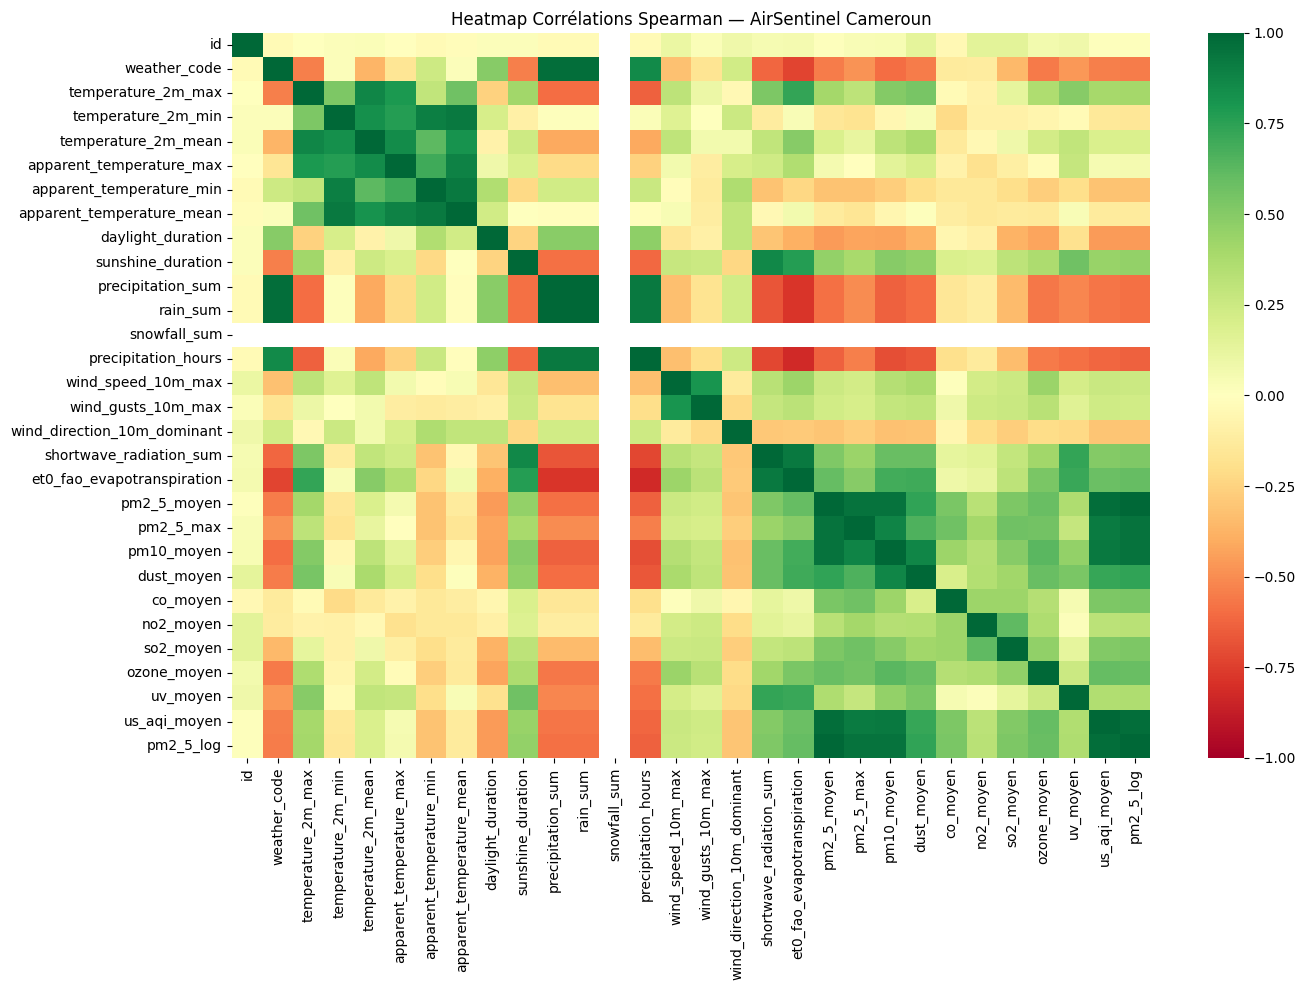

✅ Heatmap sauvegardée


In [15]:
cols_corr = [c for c in df.columns
             if df[c].dtype in ['float64', 'int64']
             and c not in ['latitude', 'longitude']]

corr_matrix = df[cols_corr].corr(method='spearman')

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=False, cmap='RdYlGn',
            center=0, vmin=-1, vmax=1)
plt.title('Heatmap Corrélations Spearman — AirSentinel Cameroun')
plt.tight_layout()
plt.savefig('../graphiques/correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()
print('✅ Heatmap sauvegardée')

In [16]:
df.to_excel('../data/processed/dataset_tests.xlsx', index=False)
print('✅ Dataset après tests sauvegardé')

✅ Dataset après tests sauvegardé
